# Part 2.2: Weather TOBS Prediction

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

## Load Data & EDA

In [3]:
df = pd.read_csv('data/weather_handout.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)
df.set_index('DATE', inplace=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDescribe:\n{df.describe()}')

Shape: (675, 6)
Date range: 2023-04-01 00:00:00 to 2025-03-31 00:00:00

Missing values:
PRCP      0
SNOW    128
SNWD    128
TMAX      0
TMIN      0
TOBS      0
dtype: int64

Describe:
             PRCP   SNOW   SNWD        TMAX        TMIN        TOBS
count  675.000000  547.0  547.0  675.000000  675.000000  675.000000
mean     0.136815    0.0    0.0   77.084444   54.311111   60.397037
std      0.395527    0.0    0.0   15.698390   16.068966   15.358215
min      0.000000    0.0    0.0   26.000000    7.000000   15.000000
25%      0.000000    0.0    0.0   66.500000   42.000000   49.000000
50%      0.000000    0.0    0.0   80.000000   58.000000   64.000000
75%      0.000000    0.0    0.0   90.000000   68.000000   73.000000
max      3.210000    0.0    0.0  106.000000   80.000000   88.000000


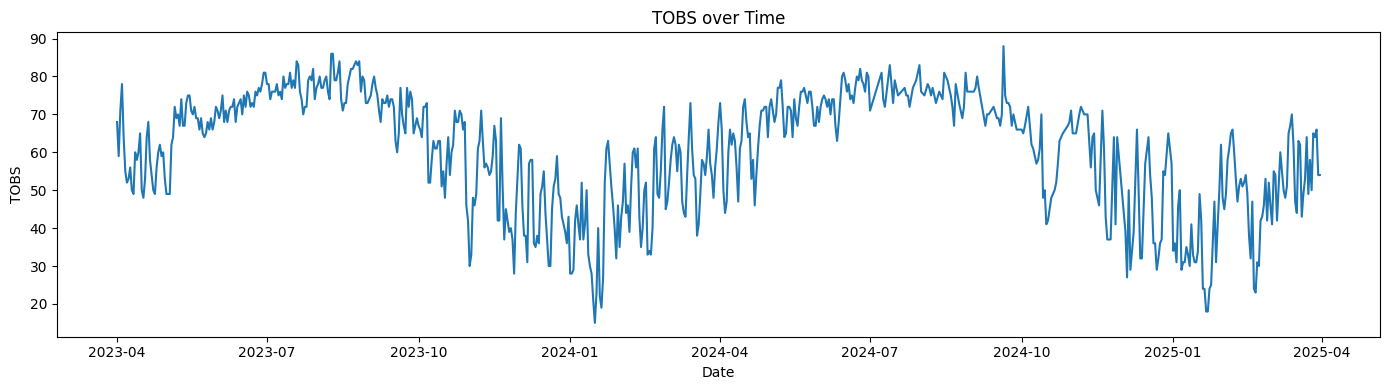

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['TOBS'])
plt.title('TOBS over Time')
plt.xlabel('Date')
plt.ylabel('TOBS')
plt.tight_layout()
plt.show()

## Handle Missing Values

In [5]:
df['SNOW'] = df['SNOW'].fillna(0)
df['SNWD'] = df['SNWD'].fillna(0)
print(f'Missing after fill:\n{df.isnull().sum()}')

Missing after fill:
PRCP    0
SNOW    0
SNWD    0
TMAX    0
TMIN    0
TOBS    0
dtype: int64


## Train/Test Split (last 3 months = test)

In [6]:
split_date = '2025-01-01'
train = df[df.index < split_date].copy()
test = df[df.index >= split_date].copy()

print(f'Train: {len(train)} ({train.index.min()} to {train.index.max()})')
print(f'Test: {len(test)} ({test.index.min()} to {test.index.max()})')

Train: 585 (2023-04-01 00:00:00 to 2024-12-31 00:00:00)
Test: 90 (2025-01-01 00:00:00 to 2025-03-31 00:00:00)


---

## Model 1: ARIMA/SARIMA

### Stationarity Test

In [7]:
result = adfuller(train['TOBS'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Stationary: {result[1] < 0.05}')

ADF Statistic: -1.8616
p-value: 0.3503
Stationary: False


### Seasonal Decomposition

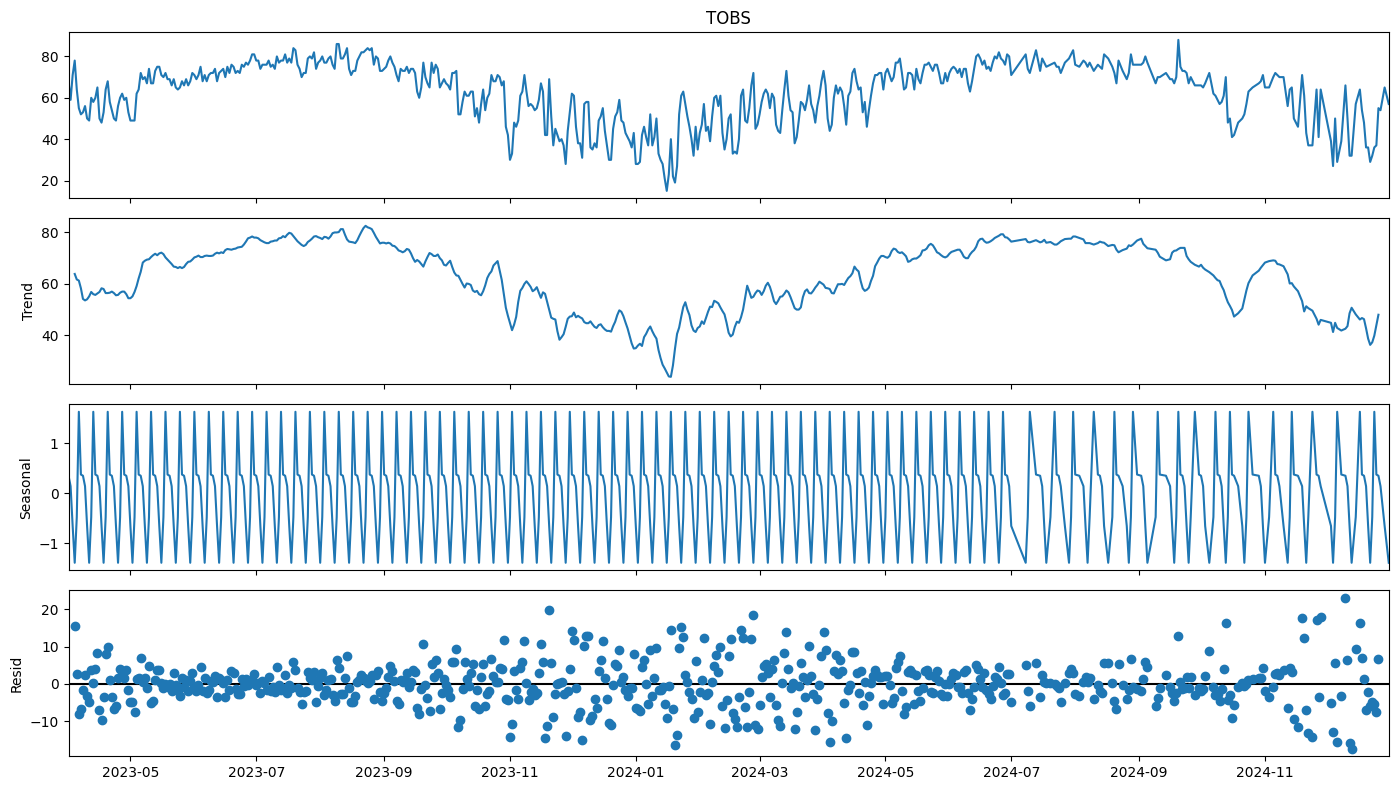

In [9]:
decomposition = seasonal_decompose(train['TOBS'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

### ACF / PACF

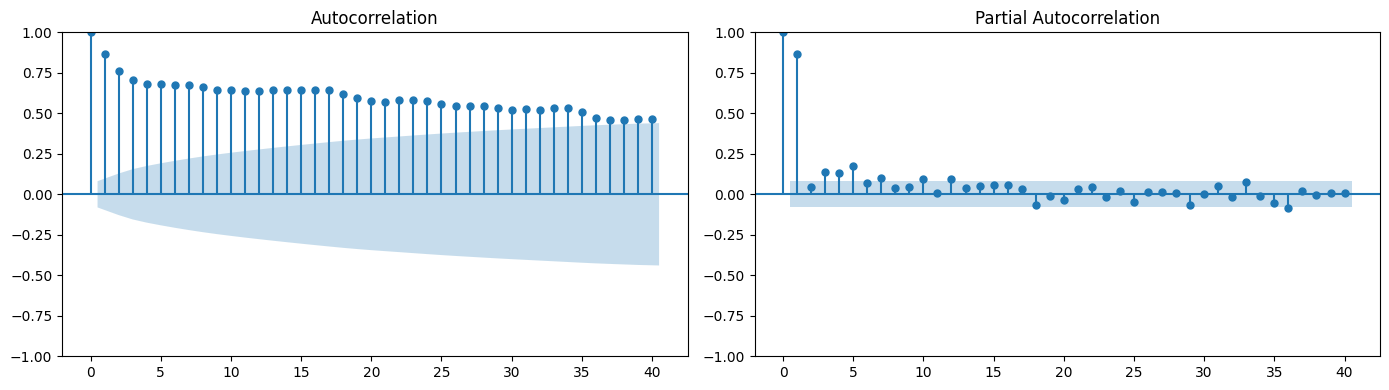

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['TOBS'], lags=40, ax=axes[0])
plot_pacf(train['TOBS'], lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

### Fit SARIMA

In [11]:
model_sarima = SARIMAX(train['TOBS'], order=(2, 0, 2), seasonal_order=(1, 1, 1, 7))
results_sarima = model_sarima.fit(disp=False)
print(results_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                TOBS   No. Observations:                  585
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood               -1944.352
Date:                             Mon, 23 Mar 2026   AIC                           3902.705
Time:                                     14:46:36   BIC                           3933.222
Sample:                                          0   HQIC                          3914.604
                                             - 585                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4266      0.073     19.569      0.000       1.284       1.570
ar.L2         -0.4295      

SARIMA — RMSE: 13.49, MAE: 10.60


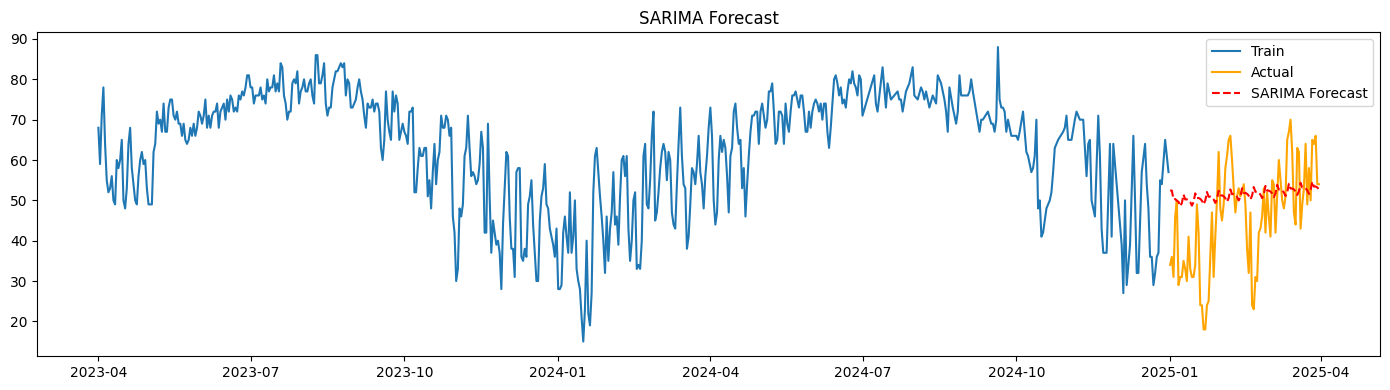

In [12]:
forecast_sarima = results_sarima.forecast(steps=len(test))
forecast_sarima.index = test.index

rmse_sarima = root_mean_squared_error(test['TOBS'], forecast_sarima)
mae_sarima = mean_absolute_error(test['TOBS'], forecast_sarima)
print(f'SARIMA — RMSE: {rmse_sarima:.2f}, MAE: {mae_sarima:.2f}')

plt.figure(figsize=(14, 4))
plt.plot(train.index, train['TOBS'], label='Train')
plt.plot(test.index, test['TOBS'], label='Actual', color='orange')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast', color='red', linestyle='--')
plt.title('SARIMA Forecast')
plt.legend()
plt.tight_layout()
plt.show()

### Diagnostics

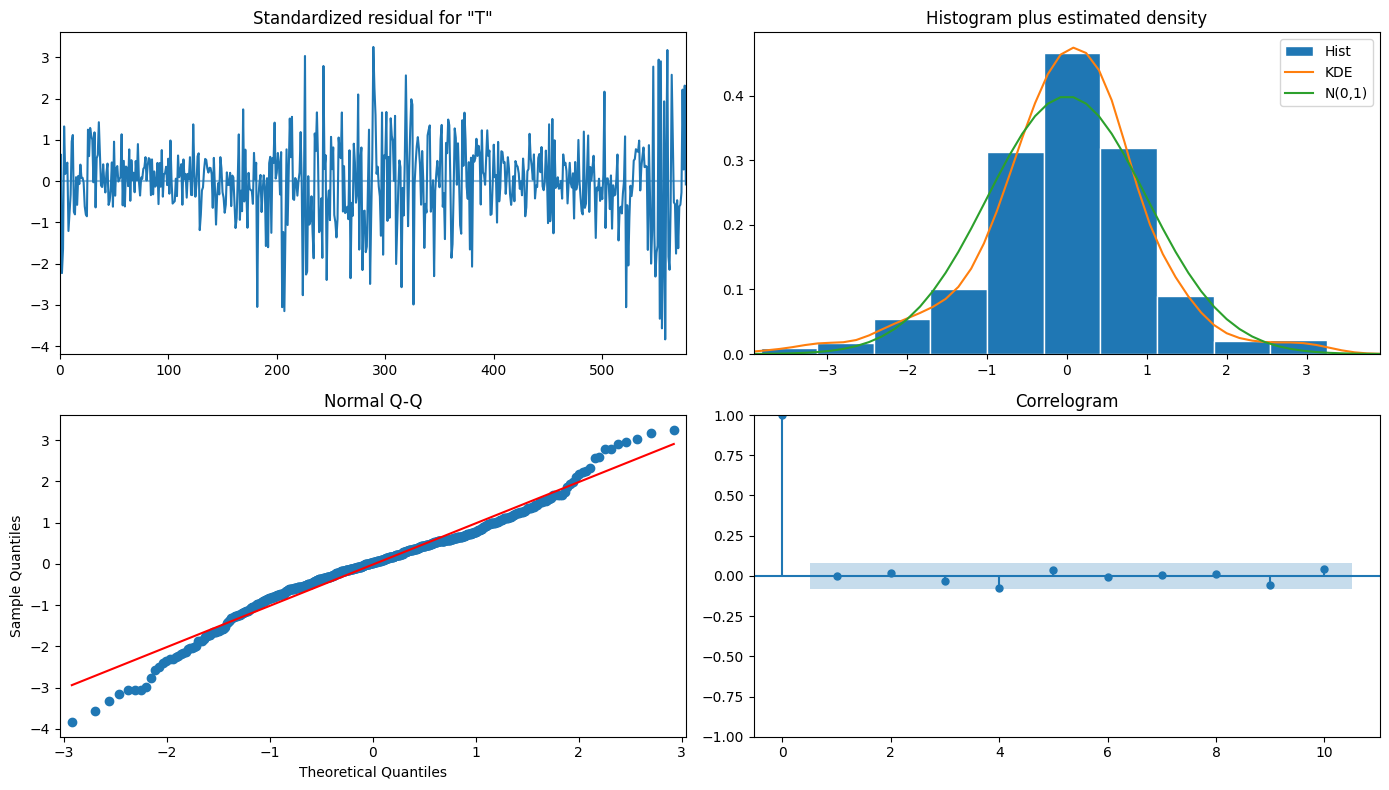

In [13]:
results_sarima.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

---

## Model 2: Lagged TOBS + Random Forest

In [14]:
n_lags = 14

df_lag = df[['TOBS']].copy()
for i in range(1, n_lags + 1):
    df_lag[f'TOBS_lag{i}'] = df_lag['TOBS'].shift(i)
df_lag = df_lag.dropna()

train_lag = df_lag[df_lag.index < split_date]
test_lag = df_lag[df_lag.index >= split_date]

lag_features = [f'TOBS_lag{i}' for i in range(1, n_lags + 1)]
X_train_lag = train_lag[lag_features]
y_train_lag = train_lag['TOBS']
X_test_lag = test_lag[lag_features]
y_test_lag = test_lag['TOBS']

print(f'Train: {len(train_lag)}, Test: {len(test_lag)}')
print(f'Features: {lag_features}')

Train: 571, Test: 90
Features: ['TOBS_lag1', 'TOBS_lag2', 'TOBS_lag3', 'TOBS_lag4', 'TOBS_lag5', 'TOBS_lag6', 'TOBS_lag7', 'TOBS_lag8', 'TOBS_lag9', 'TOBS_lag10', 'TOBS_lag11', 'TOBS_lag12', 'TOBS_lag13', 'TOBS_lag14']


Lagged RF — RMSE: 9.76, MAE: 7.78


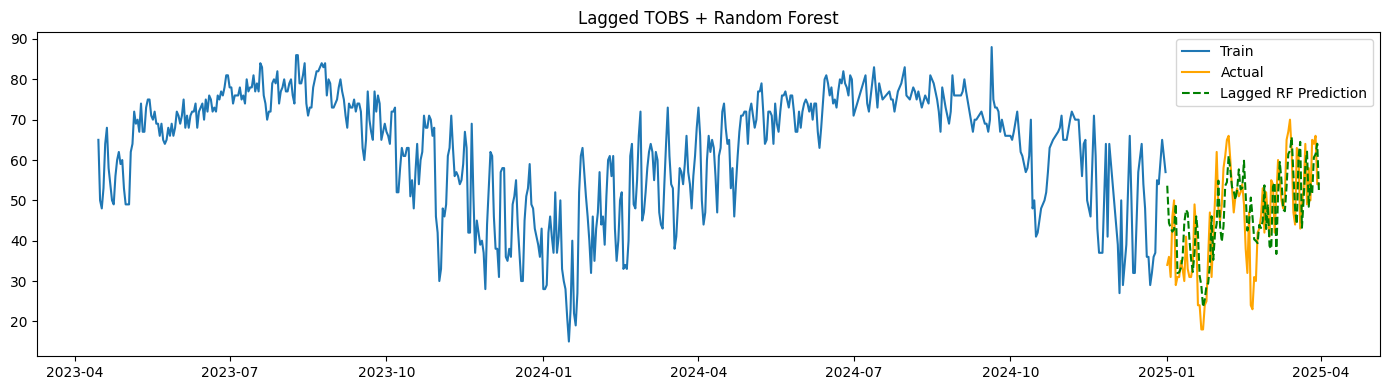

In [15]:
rf_lag = RandomForestRegressor(n_estimators=200, random_state=42)
rf_lag.fit(X_train_lag, y_train_lag)
y_pred_lag = rf_lag.predict(X_test_lag)

rmse_lag = root_mean_squared_error(y_test_lag, y_pred_lag)
mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)
print(f'Lagged RF — RMSE: {rmse_lag:.2f}, MAE: {mae_lag:.2f}')

plt.figure(figsize=(14, 4))
plt.plot(train_lag.index, train_lag['TOBS'], label='Train')
plt.plot(test_lag.index, y_test_lag, label='Actual', color='orange')
plt.plot(test_lag.index, y_pred_lag, label='Lagged RF Prediction', color='green', linestyle='--')
plt.title('Lagged TOBS + Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---

## Model 3: Other Features (no TOBS) + Random Forest

Other Features RF — RMSE: 5.79, MAE: 4.63


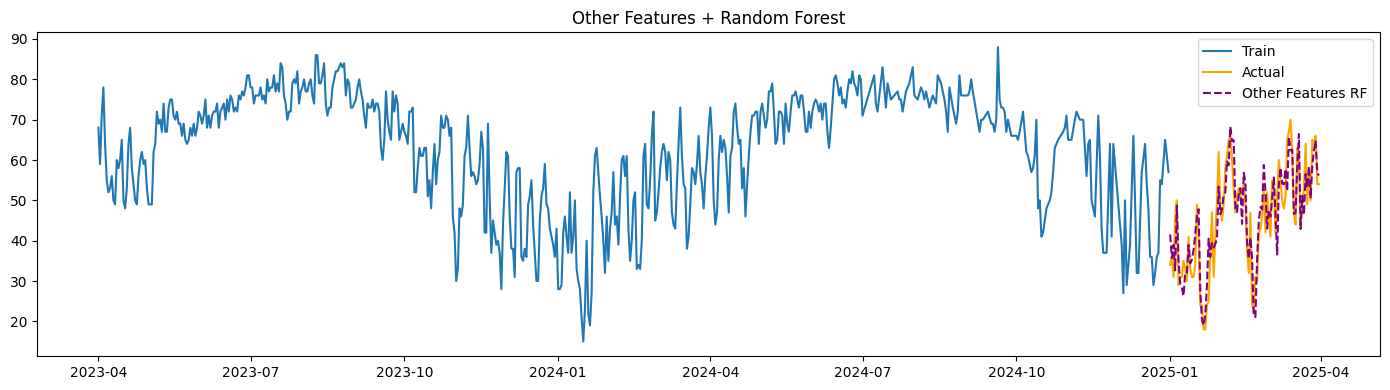

In [16]:
other_features = ['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN']

X_train_other = train[other_features]
y_train_other = train['TOBS']
X_test_other = test[other_features]
y_test_other = test['TOBS']

rf_other = RandomForestRegressor(n_estimators=200, random_state=42)
rf_other.fit(X_train_other, y_train_other)
y_pred_other = rf_other.predict(X_test_other)

rmse_other = root_mean_squared_error(y_test_other, y_pred_other)
mae_other = mean_absolute_error(y_test_other, y_pred_other)
print(f'Other Features RF — RMSE: {rmse_other:.2f}, MAE: {mae_other:.2f}')

plt.figure(figsize=(14, 4))
plt.plot(train.index, train['TOBS'], label='Train')
plt.plot(test.index, y_test_other, label='Actual', color='orange')
plt.plot(test.index, y_pred_other, label='Other Features RF', color='purple', linestyle='--')
plt.title('Other Features + Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---

## Model Comparison

              Model      RMSE       MAE
             SARIMA 13.486550 10.597862
   Lagged TOBS + RF  9.759391  7.783944
Other Features + RF  5.794034  4.634235


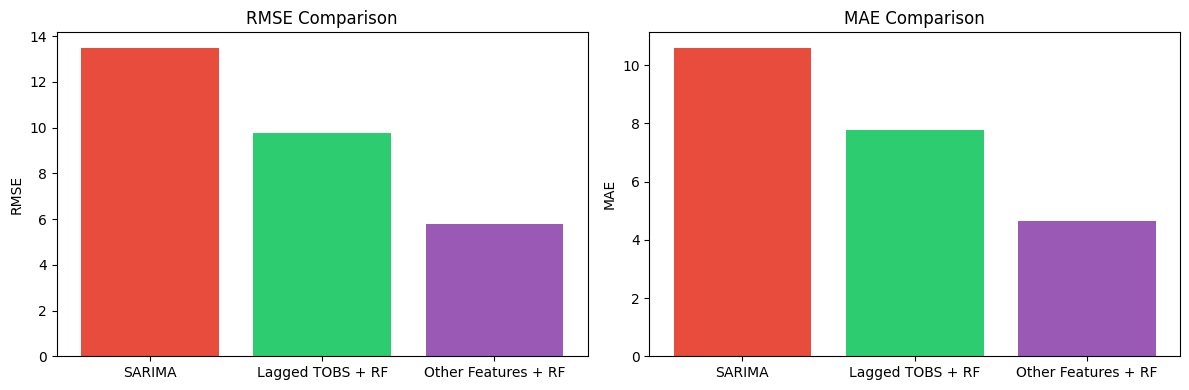

In [17]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Lagged TOBS + RF', 'Other Features + RF'],
    'RMSE': [rmse_sarima, rmse_lag, rmse_other],
    'MAE': [mae_sarima, mae_lag, mae_other]
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison['Model'], comparison['RMSE'], color=['#e74c3c', '#2ecc71', '#9b59b6'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')

axes[1].bar(comparison['Model'], comparison['MAE'], color=['#e74c3c', '#2ecc71', '#9b59b6'])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()